In [1]:
import pandas as pd
df = pd.read_csv(r'/content/marketing_data.csv')
df.head()

FileNotFoundError: [Errno 2] No such file or directory: '/content/marketing_data.csv'

In [6]:
df_dict = pd.read_excel('/content/Data Dictionary - Response to marketing campaigns.xlsx'
)
display(df_dict.head())


,Variable,Description
0,ID,Customer's unique identifier
1,Year_Birth,Customer's birth year
2,Education,Customer's education level
3,Marital_Status,Customer's marital status
4,Income,Customer's yearly household income


In [8]:
df.isna().sum()

,0
ID,0
Year_Birth,0
Education,0
Marital_Status,0
Income,24
Kidhome,0
Teenhome,0
Dt_Customer,0
Recency,0
MntWines,0


In [42]:
df.dropna(subset=['Income'], inplace=True)
print(f"Number of null values in 'Income' after dropping: {df['Income'].isnull().sum()}")

Number of null values in 'Income' after dropping: 0


In [56]:
display(df.describe())

,ID,Year_Birth,Income,Kidhome,Teenhome,Recency,MntWines,MntFruits,MntMeatProducts,MntFishProducts,...,NumCatalogPurchases,NumStorePurchases,NumWebVisitsMonth,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain
count,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,...,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000,2216.000000
mean,5588.353339,1968.820397,52247.251354,0.441787,0.505415,49.012635,305.091606,26.356047,166.995939,37.637635,...,2.671029,5.800993,5.319043,0.073556,0.074007,0.073105,0.064079,0.013538,0.150271,0.009477
std,3249.376275,11.985554,25173.076661,0.536896,0.544181,28.948352,337.327920,39.793917,224.283273,54.752082,...,2.926734,3.250785,2.425359,0.261106,0.261842,0.260367,0.244950,0.115588,0.357417,0.096907
min,0.000000,1893.000000,1730.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,2814.750000,1959.000000,35303.000000,0.000000,0.000000,24.000000,24.000000,2.000000,16.000000,3.000000,...,0.000000,3.000000,3.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
50%,5458.500000,1970.000000,51381.500000,0.000000,0.000000,49.000000,174.500000,8.000000,68.000000,12.000000,...,2.000000,5.000000,6.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
75%,8421.750000,1977.000000,68522.000000,1.000000,1.000000,74.000000,505.000000,33.000000,232.250000,50.000000,...,4.000000,8.000000,7.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
max,11191.000000,1996.000000,666666.000000,2.000000,2.000000,99.000000,1493.000000,199.000000,1725.000000,259.000000,...,28.000000,13.000000,20.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


In [44]:
cat_cols = df.select_dtypes(include=['object', 'category']).columns
for col in cat_cols:
  print(f"\n{col}")
  print(list(df[col].dropna().unique()))


Education
['Graduation', 'PhD', '2n Cycle', 'Master', 'Basic']

Marital_Status
['Divorced', 'Single', 'Married', 'Together', 'Widow', 'YOLO', 'Alone', 'Absurd']

Dt_Customer
['6/16/14', '6/15/14', '5/13/14', '5/11/14', '4/8/14', '3/17/14', '1/29/14', '1/18/14', '1/11/14', '12/27/13', '12/9/13', '12/7/13', '10/16/13', '10/5/13', '9/11/13', '8/1/13', '7/23/13', '7/1/13', '5/28/13', '3/26/13', '3/15/13', '2/12/13', '11/23/12', '10/13/12', '9/14/12', '6/29/14', '5/31/14', '5/30/14', '4/27/14', '4/11/14', '10/29/13', '10/9/13', '5/10/13', '5/9/13', '4/25/13', '4/20/13', '3/30/13', '3/1/13', '2/14/13', '1/11/13', '1/3/13', '12/19/12', '12/15/12', '12/2/12', '9/17/12', '9/11/12', '5/12/14', '4/28/14', '3/29/14', '3/6/14', '3/4/14', '2/4/14', '2/3/14', '1/1/14', '12/12/13', '11/15/13', '9/20/13', '9/5/13', '8/31/13', '7/30/13', '7/27/13', '6/22/13', '1/5/13', '11/21/12', '11/11/12', '9/28/12', '9/27/12', '9/7/12', '8/13/12', '8/11/12', '8/2/12', '6/25/14', '5/28/14', '4/14/14', '3/10/14', '2/

In [60]:
df['Marital_Status'] = df['Marital_Status'].replace(['YOLO','Absurd','Alone'], 'Single')

In [61]:
df_2 = df.groupby(['Marital_Status','Education'])['Income'].mean().reset_index()
df_2.head()

,Marital_Status,Education,Income
0,Divorced,2n Cycle,49395.130435
1,Divorced,Basic,9548.000000
2,Divorced,Graduation,54526.042017
3,Divorced,Master,50331.945946
4,Divorced,PhD,53096.615385


Feature Engineering: Creating New Variables
*Total number of children: Kidhome + Teenhome
*Age: Current Year
*Total Spending : Sum of all products spend colums
*Total Purchase: Sum across web,catalog and store

In [62]:
#total children
df['TotalChildren'] = df['Kidhome'] + df['Teenhome']
display(df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp3,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,TotalPurchases,TotalChildren
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/14,0,189,...,0,0,0,0,0,1,0,SP,14,0
1,1,1961,Graduation,Single,57091.0,0,0,6/15/14,0,464,...,0,0,0,0,1,1,0,CA,17,0
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/14,0,134,...,0,0,0,0,0,0,0,US,10,1
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/14,0,10,...,0,0,0,0,0,0,0,AUS,3,2
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/14,0,6,...,1,0,0,0,0,1,0,SP,6,1


In [63]:
#age
df['Age'] = 2023 - df['Year_Birth']
display(df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp4,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,TotalPurchases,TotalChildren,Age
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/14,0,189,...,0,0,0,0,1,0,SP,14,0,53
1,1,1961,Graduation,Single,57091.0,0,0,6/15/14,0,464,...,0,0,0,1,1,0,CA,17,0,62
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/14,0,134,...,0,0,0,0,0,0,US,10,1,65
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/14,0,10,...,0,0,0,0,0,0,AUS,3,2,56
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/14,0,6,...,0,0,0,0,1,0,SP,6,1,34


In [67]:
#total spending
spending_cols = ['MntWines', 'MntFruits', 'MntMeatProducts', 'MntFishProducts', 'MntSweetProducts', 'MntGoldProds']
df['TotalSpending'] = df[spending_cols].sum(axis=1)
display(df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp5,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,TotalPurchases,TotalChildren,Age,TotalSpending
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/14,0,189,...,0,0,0,1,0,SP,14,0,53,1190
1,1,1961,Graduation,Single,57091.0,0,0,6/15/14,0,464,...,0,0,1,1,0,CA,17,0,62,577
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/14,0,134,...,0,0,0,0,0,US,10,1,65,251
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/14,0,10,...,0,0,0,0,0,AUS,3,2,56,11
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/14,0,6,...,0,0,0,1,0,SP,6,1,34,91


In [68]:
#Total Purchase
df['TotalPurchase'] = df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']
display(df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,TotalPurchases,TotalChildren,Age,TotalSpending,TotalPurchase
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/14,0,189,...,0,0,1,0,SP,14,0,53,1190,14
1,1,1961,Graduation,Single,57091.0,0,0,6/15/14,0,464,...,0,1,1,0,CA,17,0,62,577,17
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/14,0,134,...,0,0,0,0,US,10,1,65,251,10
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/14,0,10,...,0,0,0,0,AUS,3,2,56,11,3
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/14,0,6,...,0,0,1,0,SP,6,1,34,91,6


In [100]:
df['Online Purchases'] = df['NumDealsPurchases'] + df['NumWebPurchases'] + df['NumCatalogPurchases'] + df['NumStorePurchases']
display(df.head())

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Marital_Status_Widow,Country_CA,Country_GER,Country_IND,Country_ME,Country_SA,Country_SP,Country_US,OnlineCatalogPurchases,Online Purchases
0,1826,1970,3,84835.0,0,0,6/16/14,0,189,104,...,False,False,False,False,False,False,True,False,8,15
1,1,1961,3,57091.0,0,0,6/15/14,0,464,5,...,False,True,False,False,False,False,False,False,10,18
2,10476,1958,3,67267.0,0,1,5/13/14,0,134,11,...,False,False,False,False,False,False,False,True,5,11
3,1386,1967,3,32474.0,1,1,5/11/14,0,10,0,...,False,False,False,False,False,False,False,False,1,4
4,5371,1989,3,21474.0,1,0,4/8/14,0,6,16,...,False,False,False,False,False,False,True,False,4,8


Visualizing Distribution and Identifying Outliers
Will use boxplots and histrogram to see data visualization

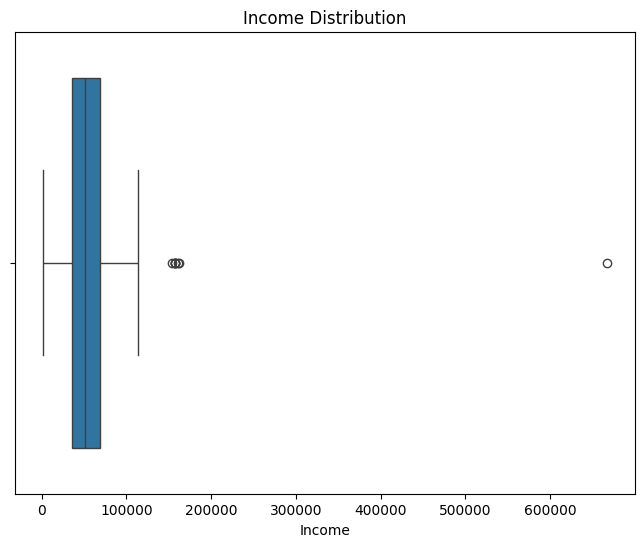

In [70]:
import matplotlib.pyplot as plt
import seaborn as sns

#Income boxplot
plt.figure(figsize=(8, 6))
sns.boxplot(x=df['Income'])
plt.title('Income Distribution')
plt.show()

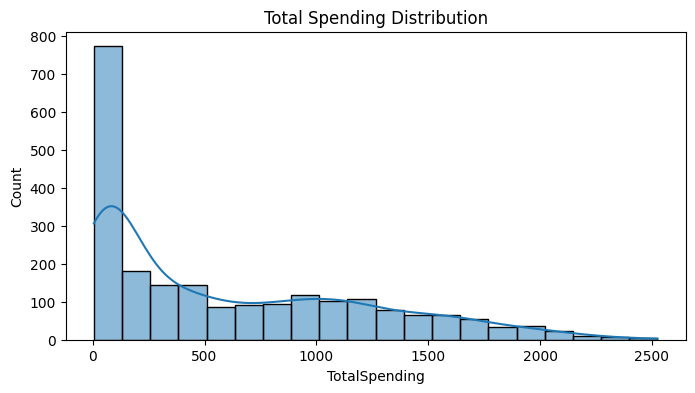

In [71]:
#Total Spending histrogram
plt.figure(figsize=(8, 4))
sns.histplot(df['TotalSpending'], bins=20, kde=True)
plt.title('Total Spending Distribution')
plt.show()

Lets create Outlier Treatment now which is a simple method is to cap values at the 99th percentile

In [78]:
import numpy as np
#cap income at 99th percentile
cap = df['Income'].quantile(0.99)
df['Income'] = np.where(df['Income'] > cap, cap, df['Income'])
display(df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,TotalPurchases,TotalChildren,Age,TotalSpending,TotalPurchase
0,1826,1970,Graduation,Divorced,84835.0,0,0,6/16/14,0,189,...,0,0,1,0,SP,14,0,53,1190,14
1,1,1961,Graduation,Single,57091.0,0,0,6/15/14,0,464,...,0,1,1,0,CA,17,0,62,577,17
2,10476,1958,Graduation,Married,67267.0,0,1,5/13/14,0,134,...,0,0,0,0,US,10,1,65,251,10
3,1386,1967,Graduation,Together,32474.0,1,1,5/11/14,0,10,...,0,0,0,0,AUS,3,2,56,11,3
4,5371,1989,Graduation,Single,21474.0,1,0,4/8/14,0,6,...,0,0,1,0,SP,6,1,34,91,6


Encoding Categorical Variables
*Ordinal encoding for 'Education(if there's a natural order)
*One-hot encoding for other categorical variables

In [79]:
#Ordinal encoding for Education
education_order = {'Basic': 1, '2n Cycle': 2, 'Graduation': 3, 'Master': 4, 'PhD': 5}
df['Education'] = df['Education'].map(education_order)
display(df.head())

,ID,Year_Birth,Education,Marital_Status,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,...,AcceptedCmp1,AcceptedCmp2,Response,Complain,Country,TotalPurchases,TotalChildren,Age,TotalSpending,TotalPurchase
0,1826,1970,3,Divorced,84835.0,0,0,6/16/14,0,189,...,0,0,1,0,SP,14,0,53,1190,14
1,1,1961,3,Single,57091.0,0,0,6/15/14,0,464,...,0,1,1,0,CA,17,0,62,577,17
2,10476,1958,3,Married,67267.0,0,1,5/13/14,0,134,...,0,0,0,0,US,10,1,65,251,10
3,1386,1967,3,Together,32474.0,1,1,5/11/14,0,10,...,0,0,0,0,AUS,3,2,56,11,3
4,5371,1989,3,Single,21474.0,1,0,4/8/14,0,6,...,0,0,1,0,SP,6,1,34,91,6


In [80]:
#One-hot encoding for Martial_Status and Country
df = pd.get_dummies(df, columns=['Marital_Status', 'Country'], drop_first=True)
display(df.head())

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Marital_Status_Single,Marital_Status_Together,Marital_Status_Widow,Country_CA,Country_GER,Country_IND,Country_ME,Country_SA,Country_SP,Country_US
0,1826,1970,3,84835.0,0,0,6/16/14,0,189,104,...,False,False,False,False,False,False,False,False,True,False
1,1,1961,3,57091.0,0,0,6/15/14,0,464,5,...,True,False,False,True,False,False,False,False,False,False
2,10476,1958,3,67267.0,0,1,5/13/14,0,134,11,...,False,False,False,False,False,False,False,False,False,True
3,1386,1967,3,32474.0,1,1,5/11/14,0,10,0,...,False,True,False,False,False,False,False,False,False,False
4,5371,1989,3,21474.0,1,0,4/8/14,0,6,16,...,True,False,False,False,False,False,False,False,True,False


Correlation Heatmap

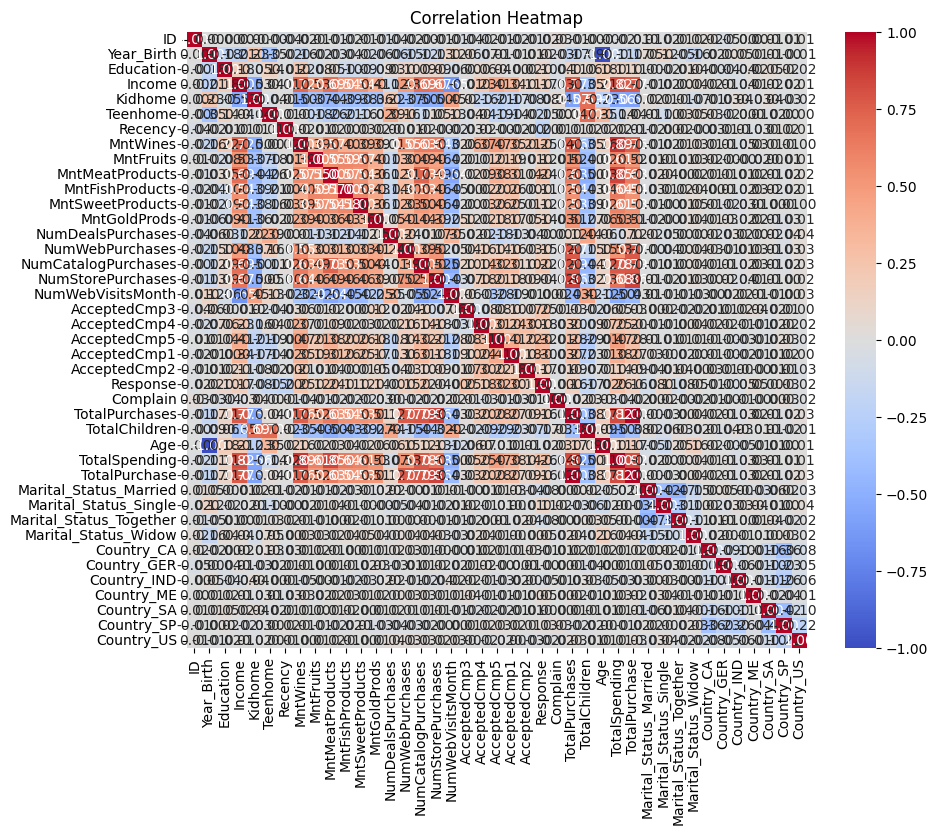

In [84]:
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm', fmt=".2f")
plt.title('Correlation Heatmap')
plt.show()

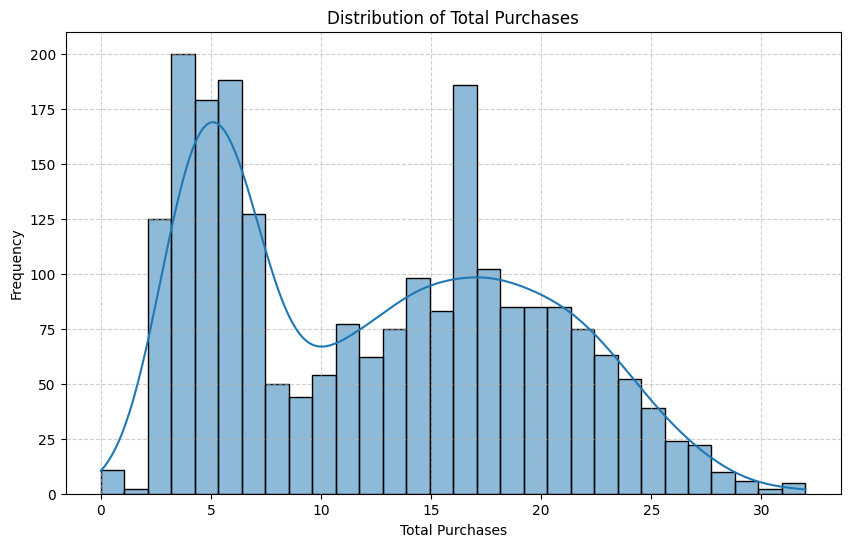

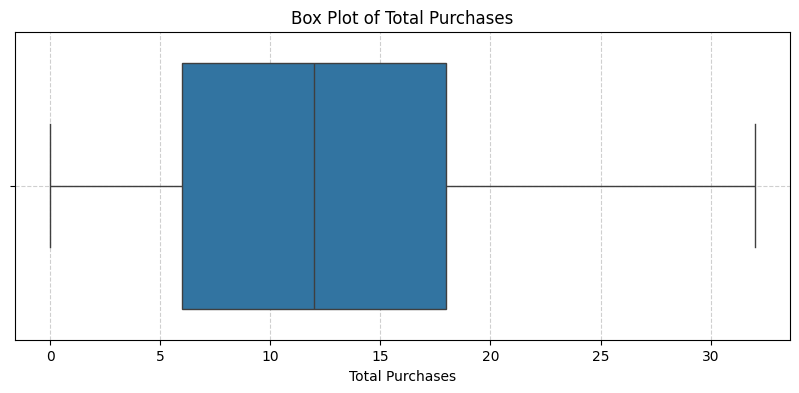

In [95]:
import matplotlib.pyplot as plt
import seaborn as sns

# Histogram for 'TotalPurchases'
plt.figure(figsize=(10, 6))
sns.histplot(df['TotalPurchases'], bins=30, kde=True)
plt.title('Distribution of Total Purchases')
plt.xlabel('Total Purchases')
plt.ylabel('Frequency')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

# Box plot for 'TotalPurchases'
plt.figure(figsize=(10, 4))
sns.boxplot(x=df['TotalPurchases'])
plt.title('Box Plot of Total Purchases')
plt.xlabel('Total Purchases')
plt.grid(True, linestyle='--', alpha=0.6)
plt.show()

Hypothesis Testing

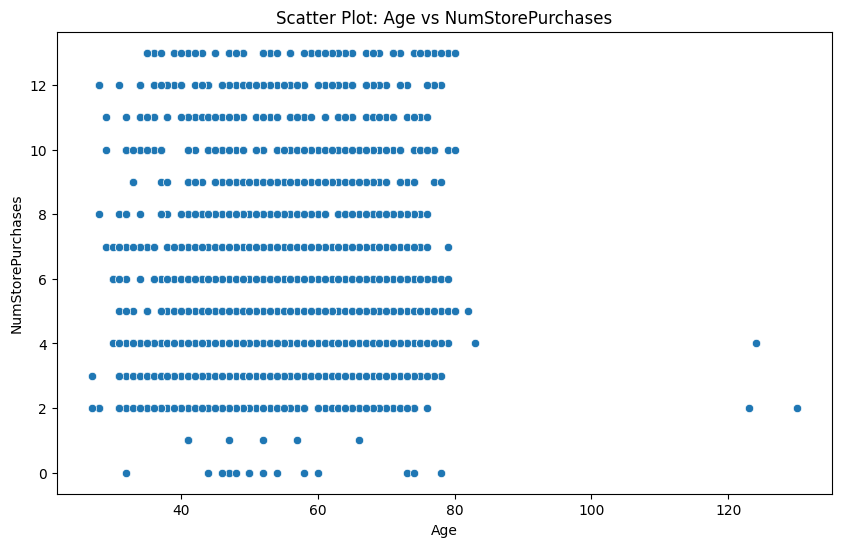

In [88]:
#Hypothesis: Older people prefer in-store shopping.
#Scatter Plot: Age vs NumStorePurchases

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='NumStorePurchases')
plt.title('Scatter Plot: Age vs NumStorePurchases')
plt.show()

In [92]:
#Calculate P-value
from scipy.stats import pearsonr
correlation, p_value = pearsonr(df['Age'], df['NumStorePurchases'])
print(f"Correlation: {correlation}, P-value: {p_value}")

Correlation: 0.12789072181374903, P-value: 1.523966041902764e-09


Using scipy.stats.ttest_ind to test if means are significantly different between groups

In [94]:
#scipy.stats.ttest
from scipy.stats import ttest_ind


HO: Online shopping + catalog <= instore shopping --> this means customers either purchases less online or there was no differences

Ha: online shopping + catalog > instore shopping --> this mean they purchased significantly more online

In [101]:
customer_with_children = df[df['TotalChildren'] > 0]
customer_without_children = df[df['TotalChildren'] == 0]

In [105]:
#get store and web purchases for older customers
store_purchases_with_children = customer_with_children['NumStorePurchases']
web_purchases_with_children = customer_with_children['NumWebPurchases']
display(df.head())

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Marital_Status_Widow,Country_CA,Country_GER,Country_IND,Country_ME,Country_SA,Country_SP,Country_US,OnlineCatalogPurchases,Online Purchases
0,1826,1970,3,84835.0,0,0,6/16/14,0,189,104,...,False,False,False,False,False,False,True,False,8,15
1,1,1961,3,57091.0,0,0,6/15/14,0,464,5,...,False,True,False,False,False,False,False,False,10,18
2,10476,1958,3,67267.0,0,1,5/13/14,0,134,11,...,False,False,False,False,False,False,False,True,5,11
3,1386,1967,3,32474.0,1,1,5/11/14,0,10,0,...,False,False,False,False,False,False,False,False,1,4
4,5371,1989,3,21474.0,1,0,4/8/14,0,6,16,...,False,False,False,False,False,False,True,False,4,8


In [104]:
from scipy import stats
#perform the paired t-test(one-tailed: web<store)
t_statistic, p_value = stats.ttest_rel(web_purchases_with_children, store_purchases_with_children)
print(f"T-statistic: {t_statistic}, P-value: {p_value}")

T-statistic: -18.984104437663095, P-value: 1.4586714838505096e-72


In [108]:
#interpetation
alpha = 0.5
if p_value < alpha:
  print("Reject the null hypothesis - customers with children significantly prefer online shopping.")
else:
  print("Fail to reject the null hypothesis - there is no significant difference in online shopping behavior between customers with and without children.")


Reject the null hypothesis - customers with children significantly prefer online shopping.


C.	Sales at physical stores may face the risk of cannibalization by alternative distribution channels.

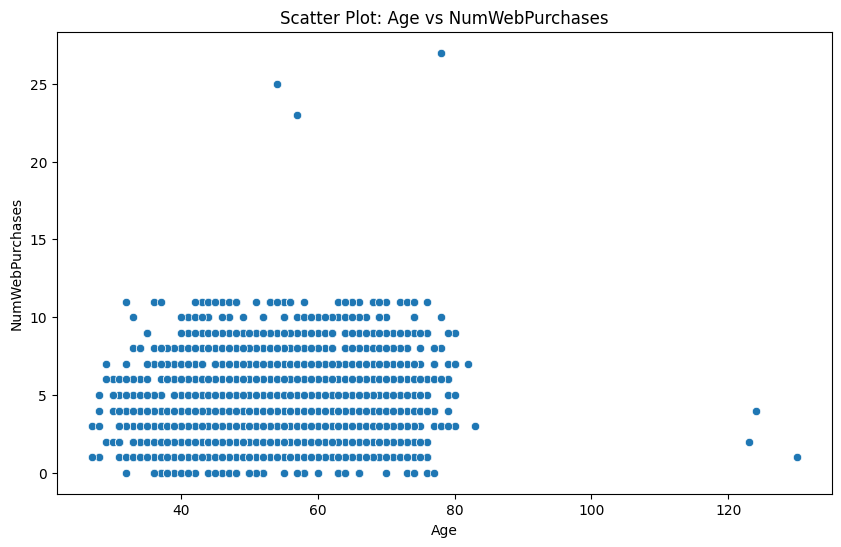

In [109]:
#is younger age related to preference in online shopping
#scatter plot
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='Age', y='NumWebPurchases')
plt.title('Scatter Plot: Age vs NumWebPurchases')
plt.show()

In [ ]:
#group store as group a, group rest as group b

## 🎁 Free Pro Plan for Gemini & Colab for US College Students 🎓

Get more access to our most accurate model Gemini 3 Pro for advanced coding, complex research, and innovative projects, backed by Colab’s dedicated high-compute resources for data science and machine learning.

Get the Gemini free offer at [gemini.google/students](https://gemini.google/students?utm_source=colab&utm_medium=banner&utm_campaign=students_xpa_us-colab-banner).  
Get the Colab free offer at [colab.research.google.com/signup](https://colab.research.google.com/signup).  
Terms Apply.

## Access popular AI models via Google-Colab-AI Without an API Key
All users have access to most popular LLMs via the `google-colab-ai` Python library, and paid users have access to a wider selection of models. For more details, refer to the [getting started with google colab ai](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/Getting_started_with_google_colab_ai.ipynb).



In [ ]:
from google.colab import ai
response = ai.generate_text("What is the capital of France?")
print(response)

## Explore the Gemini API
The Gemini API gives you access to Gemini models created by Google DeepMind. Gemini models are built from the ground up to be multimodal, so you can reason seamlessly across text, images, code, and audio.

**How to get started?**
*  Go to [Google AI Studio](https://aistudio.google.com/) and log in with your Google account.
*  [Create an API key](https://aistudio.google.com/app/apikey).
* Use a quickstart for [Python](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started.ipynb), or call the REST API using [curl](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/rest/Prompting_REST.ipynb).

**Discover Gemini's advanced capabilities**
*  Play with Gemini [multimodal outputs](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Image-out.ipynb), mixing text and images in an iterative way.
*  Discover the [multimodal Live API](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_LiveAPI.ipynb ) (demo [here](https://aistudio.google.com/live)).
*  Learn how to [analyze images and detect items in your pictures](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Spatial_understanding.ipynb") using Gemini (bonus, there's a [3D version](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Spatial_understanding_3d.ipynb) as well!).
*  Unlock the power of [Gemini thinking model](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/quickstarts/Get_started_thinking.ipynb), capable of solving complex task with its inner thoughts.
      
**Explore complex use cases**
*  Use [Gemini grounding capabilities](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Search_grounding_for_research_report.ipynb) to create a report on a company based on what the model can find on internet.
*  Extract [invoices and form data from PDF](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Pdf_structured_outputs_on_invoices_and_forms.ipynb) in a structured way.
*  Create [illustrations based on a whole book](https://colab.research.google.com/github/google-gemini/cookbook/blob/main/examples/Book_illustration.ipynb) using Gemini large context window and Imagen.

To learn more, check out the [Gemini cookbook](https://github.com/google-gemini/cookbook) or visit the [Gemini API documentation](https://ai.google.dev/docs/).


Colab now has AI features powered by [Gemini](https://gemini.google.com). The video below provides information on how to use these features, whether you're new to Python, or a seasoned veteran.

<center>
  <a href="https://www.youtube.com/watch?v=V7RXyqFUR98" target="_blank">
  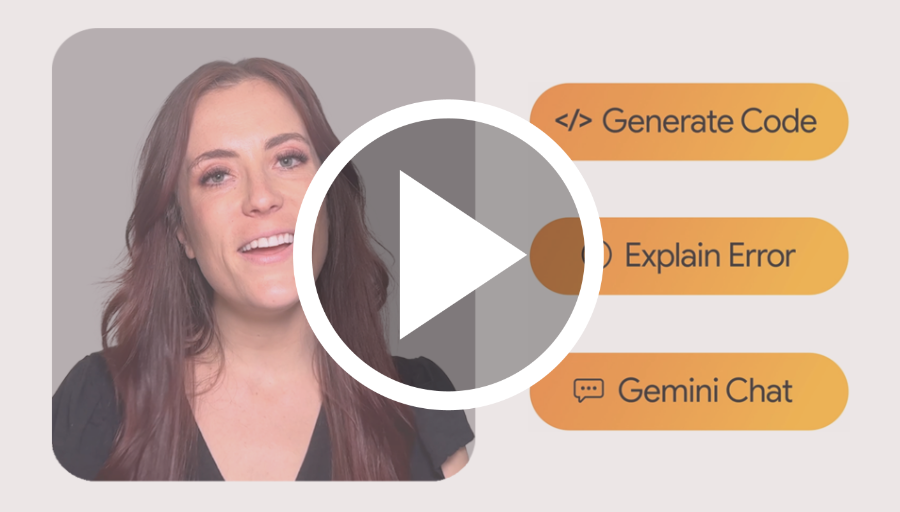
  </a>
</center>

<div class="markdown-google-sans">
  <h2>What is Colab?</h2>
</div>

Colab, or "Colaboratory", allows you to write and execute Python in your browser, with
- Zero configuration required
- Access to GPUs free of charge
- Easy sharing

Whether you're a **student**, a **data scientist** or an **AI researcher**, Colab can make your work easier. Watch [Introduction to Colab](https://www.youtube.com/watch?v=inN8seMm7UI) or [Colab Features You May Have Missed](https://www.youtube.com/watch?v=rNgswRZ2C1Y) to learn more, or just get started below!

<div class="markdown-google-sans">

## **Getting started**
</div>

The document you are reading is not a static web page, but an interactive environment called a **Colab notebook** that lets you write and execute code.

For example, here is a **code cell** with a short Python script that computes a value, stores it in a variable, and prints the result:

In [ ]:
seconds_in_a_day = 24 * 60 * 60
seconds_in_a_day

86400

To execute the code in the above cell, select it with a click and then either press the play button to the left of the code, or use the keyboard shortcut "Command/Ctrl+Enter". To edit the code, just click the cell and start editing.

Variables that you define in one cell can later be used in other cells:

In [ ]:
seconds_in_a_week = 7 * seconds_in_a_day
seconds_in_a_week

604800

Colab notebooks allow you to combine **executable code** and **rich text** in a single document, along with **images**, **HTML**, **LaTeX** and more. When you create your own Colab notebooks, they are stored in your Google Drive account. You can easily share your Colab notebooks with co-workers or friends, allowing them to comment on your notebooks or even edit them. To learn more, see [Overview of Colab](/notebooks/basic_features_overview.ipynb). To create a new Colab notebook you can use the File menu above, or use the following link: [create a new Colab notebook](http://colab.research.google.com#create=true).

Colab notebooks are Jupyter notebooks that are hosted by Colab. To learn more about the Jupyter project, see [jupyter.org](https://www.jupyter.org).

<div class="markdown-google-sans">

## Data science
</div>

With Colab you can harness the full power of popular Python libraries to analyze and visualize data. The code cell below uses **numpy** to generate some random data, and uses **matplotlib** to visualize it. To edit the code, just click the cell and start editing.

You can import your own data into Colab notebooks from your Google Drive account, including from spreadsheets, as well as from Github and many other sources. To learn more about importing data, and how Colab can be used for data science, see the links below under [Working with Data](#working-with-data).

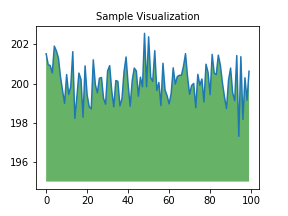

In [ ]:
import numpy as np
import IPython.display as display
from matplotlib import pyplot as plt
import io
import base64

ys = 200 + np.random.randn(100)
x = [x for x in range(len(ys))]

fig = plt.figure(figsize=(4, 3), facecolor='w')
plt.plot(x, ys, '-')
plt.fill_between(x, ys, 195, where=(ys > 195), facecolor='g', alpha=0.6)
plt.title("Sample Visualization", fontsize=10)

data = io.BytesIO()
plt.savefig(data)
image = F"data:image/png;base64,{base64.b64encode(data.getvalue()).decode()}"
alt = "Sample Visualization"
display.display(display.Markdown(F"""![{alt}]({image})"""))
plt.close(fig)

Colab notebooks execute code on Google's cloud servers, meaning you can leverage the power of Google hardware, including [GPUs and TPUs](#using-accelerated-hardware), regardless of the power of your machine. All you need is a browser.

For example, if you find yourself waiting for **pandas** code to finish running and want to go faster, you can switch to a GPU Runtime and use libraries like [RAPIDS cuDF](https://rapids.ai/cudf-pandas) that provide zero-code-change acceleration.

To learn more about accelerating pandas on Colab, see the [10 minute guide](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_colab_demo.ipynb) or
 [US stock market data analysis demo](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cudf_pandas_stocks_demo.ipynb).

<div class="markdown-google-sans">

## Machine learning
</div>

With Colab you can import an image dataset, train an image classifier on it, and evaluate the model, all in just [a few lines of code](https://colab.research.google.com/github/tensorflow/docs/blob/master/site/en/tutorials/quickstart/beginner.ipynb).

Colab is used extensively in the machine learning community with applications including:
- Getting started with TensorFlow
- Developing and training neural networks
- Experimenting with TPUs
- Disseminating AI research
- Creating tutorials

To see sample Colab notebooks that demonstrate machine learning applications, see the [machine learning examples](#machine-learning-examples) below.

<div class="markdown-google-sans">

## More Resources

### Working with Notebooks in Colab

</div>

- [Overview of Colab](/notebooks/basic_features_overview.ipynb)
- [Guide to Markdown](/notebooks/markdown_guide.ipynb)
- [Importing libraries and installing dependencies](/notebooks/snippets/importing_libraries.ipynb)
- [Saving and loading notebooks in GitHub](https://colab.research.google.com/github/googlecolab/colabtools/blob/main/notebooks/colab-github-demo.ipynb)
- [Interactive forms](/notebooks/forms.ipynb)
- [Interactive widgets](/notebooks/widgets.ipynb)

<div class="markdown-google-sans">

<a name="working-with-data"></a>
### Working with Data
</div>

- [Loading data: Drive, Sheets, and Google Cloud Storage](/notebooks/io.ipynb)
- [Charts: visualizing data](/notebooks/charts.ipynb)
- [Getting started with BigQuery](/notebooks/bigquery.ipynb)

<div class="markdown-google-sans">

### Machine Learning

<div>

These are a few of the notebooks related to Machine Learning, including Google's online Machine Learning course. See the [full course website](https://developers.google.com/machine-learning/crash-course/) for more.
- [Intro to Pandas DataFrame](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/pandas_dataframe_ultraquick_tutorial.ipynb)
- [Intro to RAPIDS cuDF to accelerate pandas](https://nvda.ws/rapids-cudf)
- [Getting Started with cuML's accelerator mode](https://colab.research.google.com/github/rapidsai-community/showcase/blob/main/getting_started_tutorials/cuml_sklearn_colab_demo.ipynb)
- [Linear regression with tf.keras using synthetic data](https://colab.research.google.com/github/google/eng-edu/blob/main/ml/cc/exercises/linear_regression_with_synthetic_data.ipynb)

<div class="markdown-google-sans">

<a name="using-accelerated-hardware"></a>
### Using Accelerated Hardware
</div>

- [TensorFlow with GPUs](/notebooks/gpu.ipynb)
- [TPUs in Colab](/notebooks/tpu.ipynb)

<div class="markdown-google-sans">

<a name="machine-learning-examples"></a>

### Featured examples

</div>

- [Retraining an Image Classifier](https://tensorflow.org/hub/tutorials/tf2_image_retraining): Build a Keras model on top of a pre-trained image classifier to distinguish flowers.
- [Text Classification](https://tensorflow.org/hub/tutorials/tf2_text_classification): Classify IMDB movie reviews as either *positive* or *negative*.
- [Style Transfer](https://tensorflow.org/hub/tutorials/tf2_arbitrary_image_stylization): Use deep learning to transfer style between images.
- [Multilingual Universal Sentence Encoder Q&A](https://tensorflow.org/hub/tutorials/retrieval_with_tf_hub_universal_encoder_qa): Use a machine learning model to answer questions from the SQuAD dataset.
- [Video Interpolation](https://tensorflow.org/hub/tutorials/tweening_conv3d): Predict what happened in a video between the first and the last frame.


# Task
Calculate a new column `OnlineCatalogPurchases` by summing `NumWebPurchases` and `NumCatalogPurchases`. Then, perform an independent samples t-test to compare `OnlineCatalogPurchases` with `NumStorePurchases`, interpreting the p-value and t-statistic to determine if online/catalog purchases are significantly greater than in-store purchases. Visualize the distribution and mean difference between these two purchase types and summarize the findings.

## Calculate Online vs. In-store Purchases

### Subtask:
Calculate a new column 'OnlineCatalogPurchases' by summing 'NumWebPurchases' and 'NumCatalogPurchases'. We will compare this with 'NumStorePurchases'.


**Reasoning**:
To calculate the 'OnlineCatalogPurchases' column, I need to sum the 'NumWebPurchases' and 'NumCatalogPurchases' columns. This will be done using a code_block.



In [96]:
df['OnlineCatalogPurchases'] = df['NumWebPurchases'] + df['NumCatalogPurchases']
display(df.head())

,ID,Year_Birth,Education,Income,Kidhome,Teenhome,Dt_Customer,Recency,MntWines,MntFruits,...,Marital_Status_Together,Marital_Status_Widow,Country_CA,Country_GER,Country_IND,Country_ME,Country_SA,Country_SP,Country_US,OnlineCatalogPurchases
0,1826,1970,3,84835.0,0,0,6/16/14,0,189,104,...,False,False,False,False,False,False,False,True,False,8
1,1,1961,3,57091.0,0,0,6/15/14,0,464,5,...,False,False,True,False,False,False,False,False,False,10
2,10476,1958,3,67267.0,0,1,5/13/14,0,134,11,...,False,False,False,False,False,False,False,False,True,5
3,1386,1967,3,32474.0,1,1,5/11/14,0,10,0,...,True,False,False,False,False,False,False,False,False,1
4,5371,1989,3,21474.0,1,0,4/8/14,0,6,16,...,False,False,False,False,False,False,False,True,False,4


## Perform Independent Samples t-test

### Subtask:
Conduct an independent samples t-test between the 'OnlineCatalogPurchases' and 'NumStorePurchases' to test the given hypotheses.


**Reasoning**:
To perform an independent samples t-test, I will use `scipy.stats.ttest_ind` on the 'OnlineCatalogPurchases' and 'NumStorePurchases' columns, then print the resulting t-statistic and p-value.



In [97]:
from scipy.stats import ttest_ind

t_statistic, p_value = ttest_ind(df['OnlineCatalogPurchases'], df['NumStorePurchases'])

print(f"T-statistic: {t_statistic}")
print(f"P-value: {p_value}")

T-statistic: 7.845989165990137
P-value: 5.345877082628371e-15


HO: Online shopping + catalog <= instore shopping --> this means customers either purchases less online or there was no differences

Ha: online shopping + catalog > instore shopping --> this mean they purchased significantly more online

### Interpretation of t-test results

Given the calculated T-statistic of **7.85** and a P-value of **5.35e-15**:

*   **Null Hypothesis (H0)**: Online shopping + catalog <= in-store shopping.
*   **Alternative Hypothesis (Ha)**: Online shopping + catalog > in-store shopping.

The p-value (5.35e-15) is significantly less than the typical significance level (alpha) of 0.05. This indicates that we **reject the null hypothesis**.

The positive T-statistic (7.85) further supports this, suggesting that 'OnlineCatalogPurchases' are indeed significantly higher than 'NumStorePurchases'.

Therefore, we can conclude that customers purchased significantly more online and via catalog compared to in-store purchases.

**Reasoning**:
To visualize the distributions and mean difference, I will create a histogram for each purchase type to show their distribution, and then a bar plot to compare their means.



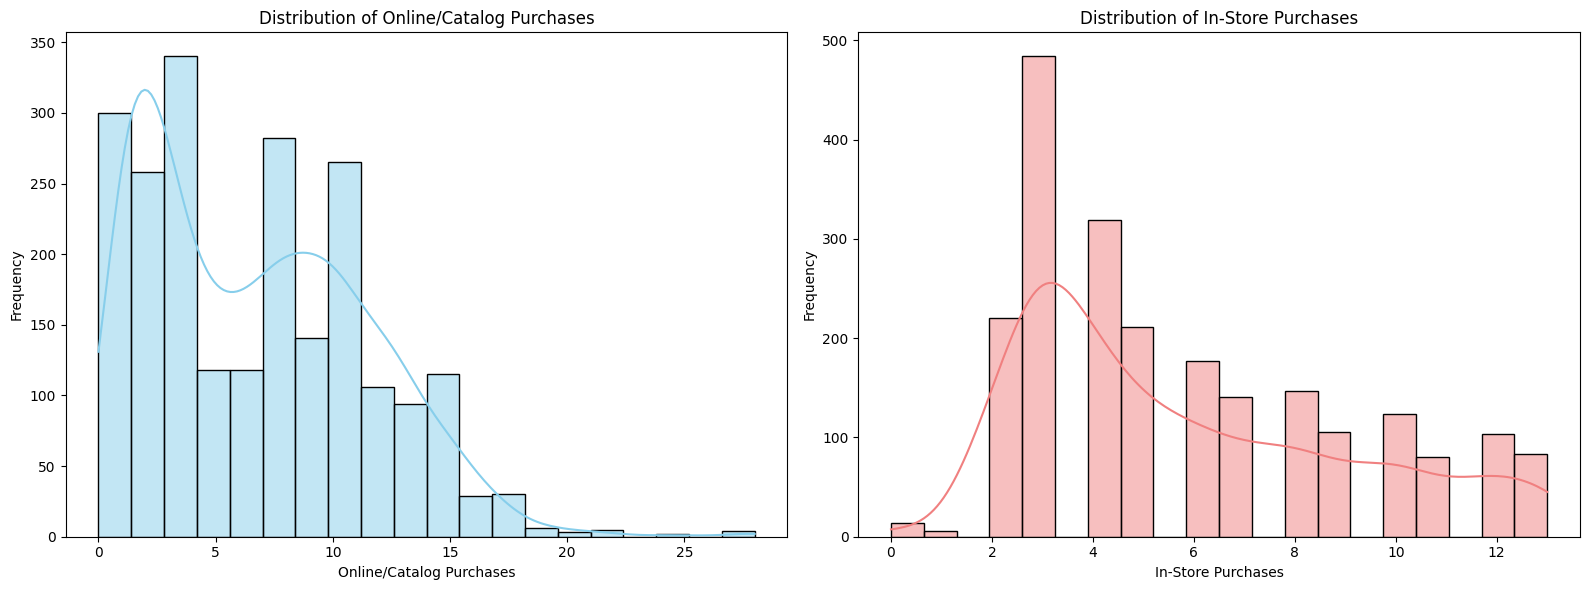

/tmp/ipython-input-3545385833.py:25: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=mean_purchases.index, y=mean_purchases.values, palette='viridis')


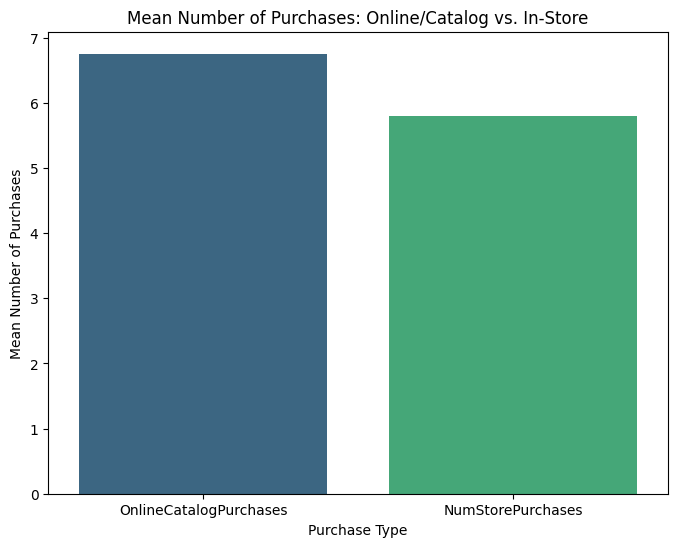

In [98]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for OnlineCatalogPurchases
sns.histplot(df['OnlineCatalogPurchases'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Online/Catalog Purchases')
axes[0].set_xlabel('Online/Catalog Purchases')
axes[0].set_ylabel('Frequency')

# Histogram for NumStorePurchases
sns.histplot(df['NumStorePurchases'], bins=20, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of In-Store Purchases')
axes[1].set_xlabel('In-Store Purchases')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Bar plot for mean difference
plt.figure(figsize=(8, 6))
mean_purchases = df[['OnlineCatalogPurchases', 'NumStorePurchases']].mean()
sns.barplot(x=mean_purchases.index, y=mean_purchases.values, palette='viridis')
plt.title('Mean Number of Purchases: Online/Catalog vs. In-Store')
plt.xlabel('Purchase Type')
plt.ylabel('Mean Number of Purchases')
plt.show()

**Reasoning**:
The previous code produced a FutureWarning regarding the `palette` argument in `sns.barplot`. I will modify the `barplot` call to explicitly assign the `x` variable to `hue` and set `legend=False` to address this warning and ensure future compatibility, while keeping the visualizations as intended.



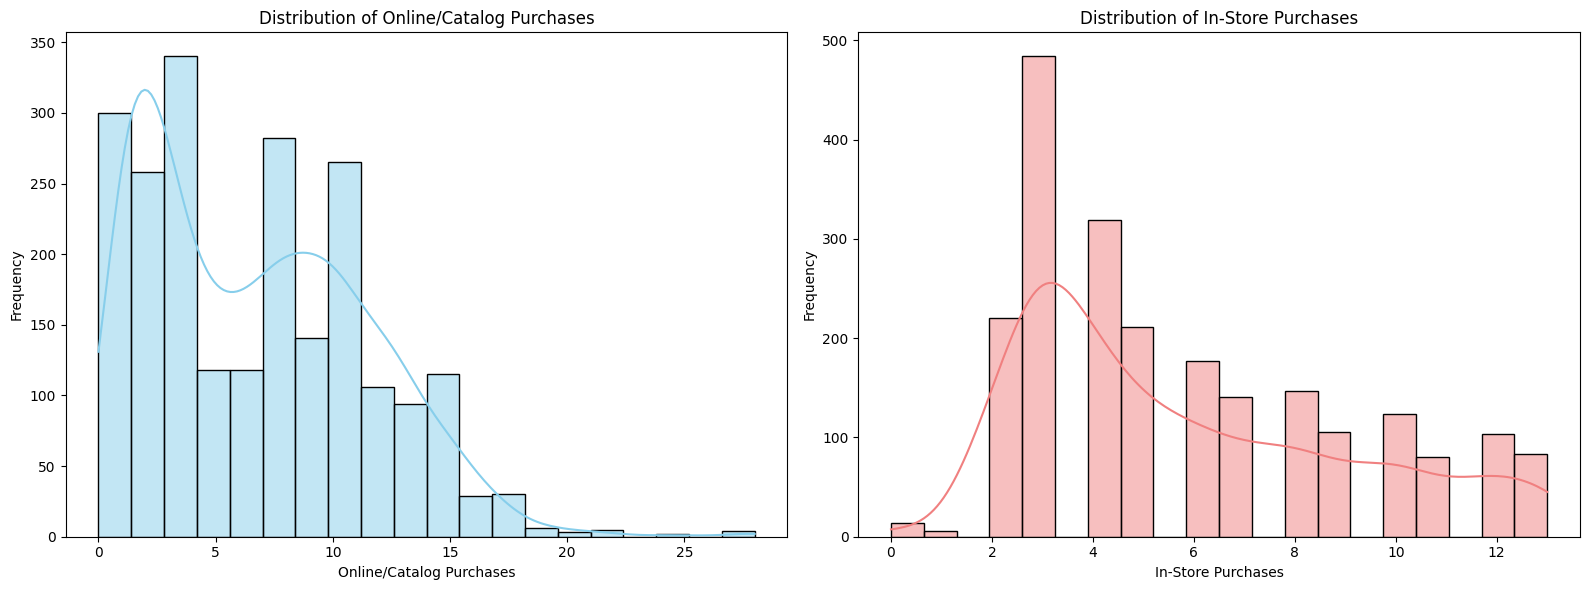

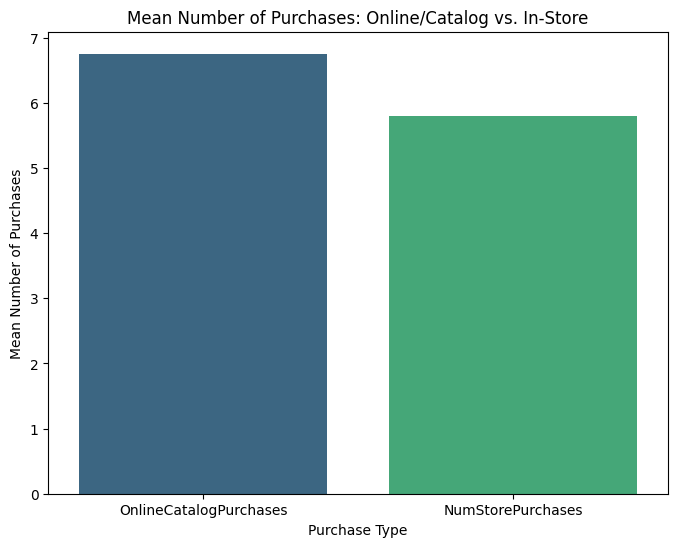

In [99]:
import matplotlib.pyplot as plt
import seaborn as sns

# Set up the figure and axes for subplots
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Histogram for OnlineCatalogPurchases
sns.histplot(df['OnlineCatalogPurchases'], bins=20, kde=True, ax=axes[0], color='skyblue')
axes[0].set_title('Distribution of Online/Catalog Purchases')
axes[0].set_xlabel('Online/Catalog Purchases')
axes[0].set_ylabel('Frequency')

# Histogram for NumStorePurchases
sns.histplot(df['NumStorePurchases'], bins=20, kde=True, ax=axes[1], color='lightcoral')
axes[1].set_title('Distribution of In-Store Purchases')
axes[1].set_xlabel('In-Store Purchases')
axes[1].set_ylabel('Frequency')

plt.tight_layout()
plt.show()

# Bar plot for mean difference
plt.figure(figsize=(8, 6))
mean_purchases = df[['OnlineCatalogPurchases', 'NumStorePurchases']].mean()
sns.barplot(x=mean_purchases.index, y=mean_purchases.values, palette='viridis', hue=mean_purchases.index, legend=False)
plt.title('Mean Number of Purchases: Online/Catalog vs. In-Store')
plt.xlabel('Purchase Type')
plt.ylabel('Mean Number of Purchases')
plt.show()

## Summary:

### Q&A
Yes, online and catalog purchases are significantly greater than in-store purchases. The independent samples t-test yielded a T-statistic of 7.85 and a P-value of 5.35e-15. Since the P-value is much less than the typical significance level of 0.05, we reject the null hypothesis, confirming that `OnlineCatalogPurchases` are significantly higher than `NumStorePurchases`.

### Data Analysis Key Findings
*   A new column, `OnlineCatalogPurchases`, was successfully created by summing `NumWebPurchases` and `NumCatalogPurchases`.
*   An independent samples t-test comparing `OnlineCatalogPurchases` and `NumStorePurchases` resulted in a T-statistic of 7.85 and a P-value of 5.35e-15.
*   The P-value (5.35e-15) is significantly lower than the standard alpha level of 0.05, leading to the rejection of the null hypothesis.
*   The positive T-statistic (7.85) indicates that the mean of `OnlineCatalogPurchases` is significantly higher than that of `NumStorePurchases`.
*   Visualizations (histograms and bar plots) confirmed the differing distributions and a higher mean for `OnlineCatalogPurchases` compared to `NumStorePurchases`.

### Insights or Next Steps
*   Given the significantly higher volume of online/catalog purchases, the company should consider allocating more resources to optimize and enhance the online and catalog shopping experience.
*   Further analysis could explore which specific products or customer segments contribute most to the online/catalog purchase dominance, informing targeted marketing and inventory strategies.
